# Ensemble — MSConvGRU v3 + MSConvFormer v1

No retraining. Combines two pre-trained models:
- **MSConvGRU v3**: Multi-Scale Conv1D + GRU + channel shift augmentation
- **MSConvFormer v1**: Multi-Scale Conv1D + Transformer + subject-adversarial training

Zero-shot: average softmax probabilities from both models.
Calibrated: LogReg on concatenated features from both models (512-dim).

## Imports

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from config import (
    RANDOM_SEED, N_CLASSES, N_CHANNELS, WINDOW_SIZE,
    MODELS_DIR, FIGURES_DIR, get_device,
    SUBJECTS_FATIGUE, SUBJECTS_NON_FATIGUE,
    SUBJECTS_INTERDAY_LONG, SUBJECTS_INTERDAY_SHORT,
    GESTURE_CLASSES,
)
from src.experiment_runner import (
    TEST_SUBJECTS, TRAIN_SUBJECTS, META, get_splits,
    load_and_norm, run_zero_shot, run_calibration, print_comparison,
)
from src.evaluation import measure_latency, print_latency

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Model Architectures (both needed for loading weights)

In [2]:
class ECA1d(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        import math
        k = int(abs(math.log2(channels) + b) / gamma)
        k = k if k % 2 else k + 1
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        w = self.avg(x).transpose(-1, -2)
        w = torch.sigmoid(self.conv(w)).transpose(-1, -2)
        return x * w


class SepConv1d(nn.Module):
    def __init__(self, ic, oc, k, p=0):
        super().__init__()
        if p == 0:
            p = k // 2
        self.dw = nn.Conv1d(ic, ic, k, padding=p, groups=ic)
        self.pw = nn.Conv1d(ic, oc, 1)

    def forward(self, x):
        return self.pw(self.dw(x))


class TemporalAttention(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(seq_len, seq_len // 2),
            nn.ReLU(),
            nn.Linear(seq_len // 2, seq_len),
            nn.Sigmoid(),
        )

    def forward(self, x):
        avg_pool = x.mean(dim=1)
        weights = self.fc(avg_pool).unsqueeze(1)
        return x * weights


# ==================== MSConvGRU (for v3) ====================
class MSConvGRU(nn.Module):
    def __init__(self, in_ch=N_CHANNELS, n_classes=N_CLASSES, seq_len=WINDOW_SIZE):
        super().__init__()
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU()
        )
        ms_out = 96
        self.eca_ms = ECA1d(ms_out)
        self.sep1 = SepConv1d(ms_out, 128, 5)
        self.bn1 = nn.BatchNorm1d(128)
        self.eca1 = ECA1d(128)
        self.res_proj1 = nn.Conv1d(ms_out, 128, 1)
        self.sep2 = SepConv1d(128, 128, 3)
        self.bn2 = nn.BatchNorm1d(128)
        self.eca2 = ECA1d(128)
        self.temporal_attn = TemporalAttention(seq_len)
        self.gru = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, n_classes)

    def _cnn_features(self, x):
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = self.eca_ms(ms)
        res = self.res_proj1(ms)
        out = F.relu(self.bn1(self.sep1(ms)))
        out = self.eca1(out)
        out = out + res
        res2 = out
        out = F.relu(self.bn2(self.sep2(out)))
        out = self.eca2(out)
        out = out + res2
        out = self.temporal_attn(out)
        return out

    def forward(self, x):
        out = self._cnn_features(x)
        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

    def extract_feat(self, x):
        out = self._cnn_features(x)
        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        return out[:, -1, :]

    def extract_feat_cnn(self, x):
        return self._cnn_features(x).mean(dim=2)


# ==================== MSConvFormer (for v1) ====================
class MSConvFormer(nn.Module):
    def __init__(self, in_ch=N_CHANNELS, n_classes=N_CLASSES, seq_len=WINDOW_SIZE):
        super().__init__()
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU()
        )
        ms_out = 96
        self.eca_ms = ECA1d(ms_out)
        self.sep1 = SepConv1d(ms_out, 128, 5)
        self.bn1 = nn.BatchNorm1d(128)
        self.eca1 = ECA1d(128)
        self.res_proj1 = nn.Conv1d(ms_out, 128, 1)
        self.sep2 = SepConv1d(128, 128, 3)
        self.bn2 = nn.BatchNorm1d(128)
        self.eca2 = ECA1d(128)
        self.cls_token = nn.Parameter(torch.randn(1, 1, 128) * 0.02)
        self.pos_enc = nn.Parameter(torch.randn(1, seq_len + 1, 128) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True, activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, n_classes)

    def _cnn_features(self, x):
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = self.eca_ms(ms)
        res = self.res_proj1(ms)
        out = F.relu(self.bn1(self.sep1(ms)))
        out = self.eca1(out)
        out = out + res
        res2 = out
        out = F.relu(self.bn2(self.sep2(out)))
        out = self.eca2(out)
        out = out + res2
        return out

    def _transformer_features(self, cnn_out):
        x = cnn_out.transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_enc[:, :x.size(1), :]
        x = self.transformer(x)
        return x[:, 0, :]

    def forward(self, x):
        cnn_out = self._cnn_features(x)
        feat = self._transformer_features(cnn_out)
        return self.fc(self.dropout(feat))

    def extract_feat(self, x):
        cnn_out = self._cnn_features(x)
        return self._transformer_features(cnn_out)

    def extract_feat_cnn(self, x):
        return self._cnn_features(x).mean(dim=2)


print("Architectures defined.")

Architectures defined.


## Load Both Models

In [3]:
model_gru = MSConvGRU().to(DEVICE)
model_gru.load_state_dict(torch.load(MODELS_DIR / "msgru_v3.pt", map_location=DEVICE))
model_gru.eval()
p1 = sum(p.numel() for p in model_gru.parameters())
print(f"MSConvGRU v3 loaded ({p1:,} params)")

model_tf = MSConvFormer().to(DEVICE)
model_tf.load_state_dict(torch.load(MODELS_DIR / "msconvformer_v1.pt", map_location=DEVICE))
model_tf.eval()
p2 = sum(p.numel() for p in model_tf.parameters())
print(f"MSConvFormer v1 loaded ({p2:,} params)")

total_params = p1 + p2
print(f"Ensemble total: {total_params:,} params")

MSConvGRU v3 loaded (125,059 params)
MSConvFormer v1 loaded (319,604 params)
Ensemble total: 444,663 params


## Load Data

In [4]:
splits = get_splits()
train_combined = pd.concat([splits["train_df"], splits["s5_train"]]).drop_duplicates()
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f"Training data: {X_train.shape}")

Loading windows: 100%|██████████| 9021/9021 [00:03<00:00, 2727.40it/s]


Training data: (1030712, 8, 50)


## Ensemble Inference

In [5]:
@torch.no_grad()
def ensemble_predict(X):
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    preds = []
    for (xb,) in loader:
        p1 = F.softmax(model_gru(xb), dim=1)
        p2 = F.softmax(model_tf(xb), dim=1)
        avg = (p1 + p2) / 2
        preds.append(avg.argmax(1).cpu().numpy())
    return np.concatenate(preds)


@torch.no_grad()
def ensemble_features(X):
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    feats = []
    for (xb,) in loader:
        f1_cnn = model_gru.extract_feat_cnn(xb)
        f1_seq = model_gru.extract_feat(xb)
        f2_cnn = model_tf.extract_feat_cnn(xb)
        f2_seq = model_tf.extract_feat(xb)
        combined = torch.cat([f1_cnn, f1_seq, f2_cnn, f2_seq], dim=1)
        feats.append(combined.cpu().numpy())
    return np.concatenate(feats)


def ensemble_finetune(X_cal, y_cal):
    F = ensemble_features(X_cal)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(F, y_cal)
    def predict_ft(X):
        return clf.predict(ensemble_features(X))
    return predict_ft


print("Ensemble functions ready.")
print("Feature dim: 128 (GRU CNN) + 128 (GRU hidden) + 128 (TF CNN) + 128 (TF CLS) = 512")

Ensemble functions ready.
Feature dim: 128 (GRU CNN) + 128 (GRU hidden) + 128 (TF CNN) + 128 (TF CLS) = 512


## S1-S5 Zero-shot

In [6]:
print("Zero-shot (ensemble avg probabilities):")
zero_results = run_zero_shot(ensemble_predict, splits, norm_stats, name="Ensemble")

Zero-shot (ensemble avg probabilities):
  S1 zero-shot: 0.6716
  S2 zero-shot: 0.6481
  S3 zero-shot: 0.6502
  S4 zero-shot: 0.7588
  S5 zero-shot: 0.8379


## S1-S5 Calibrated

In [7]:
print("\nCalibrated (LogReg on 512-dim ensemble features):")
cal_results = run_calibration(ensemble_predict, ensemble_finetune, splits, norm_stats, name="Ensemble")


Calibrated (LogReg on 512-dim ensemble features):
  S1 calibrated: 0.8565
  S2 calibrated: 0.8663
  S3 calibrated: 0.9056
  S4 calibrated: 0.8875
  S5 calibrated: 0.9014


## S6: Combined Factor

In [8]:
s6_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] > 0)
]
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, ensemble_predict(X_s6))
print(f"S6 zero-shot: {s6_zs:.4f}")

s6_cal_accs = []
for subj in sorted(TEST_SUBJECTS):
    sdf = s6_test[s6_test["subject"] == subj]
    cal_df = sdf[sdf["repetition"].isin([0, 1])]
    te_df = sdf[sdf["repetition"] == 2]
    if len(cal_df) == 0 or len(te_df) == 0:
        continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)
    ft = ensemble_finetune(X_c, y_c)
    acc = accuracy_score(y_t, ft(X_t))
    s6_cal_accs.append(acc)
    print(f"  {subj}: {acc:.4f}")

s6_cal = np.mean(s6_cal_accs) if s6_cal_accs else float("nan")
print(f"S6 calibrated avg: {s6_cal:.4f}")

S6 zero-shot: 0.6481
  h16: 0.9329
  h17: 0.9013
  h22: 0.8881
  h24: 0.9029
  h3: 0.8860
  h7: 0.9534
S6 calibrated avg: 0.9108


## S7: Gradual Electrode Shift

  Position  0: 0.8406
  Position  1: 0.8628
  Position  2: 0.8779
  Position  3: 0.8742
  Position  4: 0.8562
  Position  5: 0.8773
  Position  6: 0.8685
  Position  7: 0.8575
  Position  8: 0.8599
  Position  9: 0.8626
  Position 10: 0.8657

P0 baseline: 0.8406, Avg shifted: 0.8663, Degradation: -2.56%


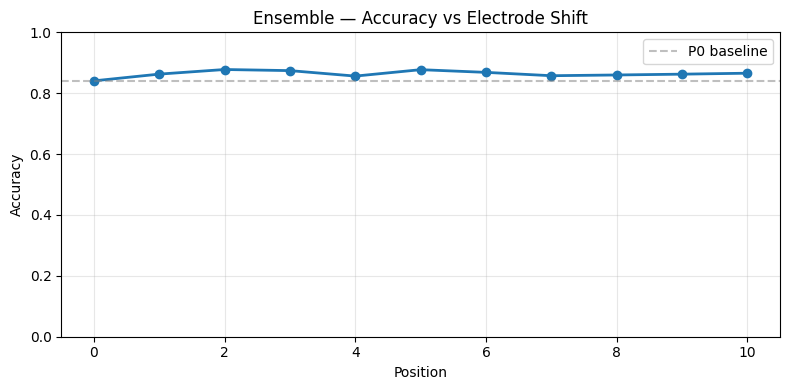

In [9]:
shift_subjects = [f"h{i}" for i in range(24, 30)]
shift_data = META[(META["subject"].isin(shift_subjects)) & (META["session"] == 0)]

s7_acc = {}
for pos in sorted(shift_data["position"].unique()):
    pos_df = shift_data[shift_data["position"] == pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, ensemble_predict(X_p))
    print(f"  Position {pos:2d}: {s7_acc[pos]:.4f}")

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p > 0])
print(f"\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, "
      f"Degradation: {(baseline - avg_shifted) * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), "o-", linewidth=2)
plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5, label="P0 baseline")
plt.xlabel("Position")
plt.ylabel("Accuracy")
plt.title("Ensemble — Accuracy vs Electrode Shift")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "ensemble_shift.png"), dpi=150)
plt.show()

## S8: Few-Shot Calibration

In [10]:
subset_s8 = META[(META["session"] == 0) & (META["subject"].isin(TEST_SUBJECTS))]

configs = [
    ("Zero-shot",        [],     False, 0),
    ("1 rep, p0 only",   [0],    True,  7),
    ("1 rep, all pos",   [0],    False, 77),
    ("2 rep, p0 only",   [0, 1], True,  14),
    ("2 rep, all pos",   [0, 1], False, 154),
]

s8_results = {}
for label, reps, p0_only, n_trials in configs:
    cal_accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8["subject"] == subj]
        if len(reps) == 0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            cal_accs.append(accuracy_score(y_t, ensemble_predict(X_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf["repetition"].isin(reps)) & (sdf["position"] == 0)]
        else:
            cal_df = sdf[sdf["repetition"].isin(reps)]
        te_df = sdf[sdf["repetition"] == 2]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)
        ft = ensemble_finetune(X_c, y_c)
        cal_accs.append(accuracy_score(y_t, ft(X_t)))
    s8_results[label] = np.mean(cal_accs) if cal_accs else float("nan")
    print(f"  {label:20s}: {s8_results[label]:.4f}  (~{n_trials} trials)")

  Zero-shot           : 0.6500  (~0 trials)
  1 rep, p0 only      : 0.6446  (~7 trials)
  1 rep, all pos      : 0.8804  (~77 trials)
  2 rep, p0 only      : 0.7205  (~14 trials)
  2 rep, all pos      : 0.9056  (~154 trials)


## Latency

In [11]:
sample = X_train[:1]

def single_predict(x):
    t = torch.FloatTensor(x).to(DEVICE)
    with torch.no_grad():
        p1 = F.softmax(model_gru(t), dim=1)
        p2 = F.softmax(model_tf(t), dim=1)
        return ((p1 + p2) / 2).argmax(1).cpu().numpy()

latency = measure_latency(single_predict, sample, n_runs=500)
print_latency(latency, model_name="Ensemble (GRU + Transformer)")


Latency — Ensemble (GRU + Transformer)
  Mean:   10.94 ms
  Median: 9.91 ms
  P95:    12.05 ms
  <300ms: ✓


## Summary

In [12]:
print()
print("=" * 65)
print("  ENSEMBLE (MSConvGRU v3 + MSConvFormer v1) -- RESULTS")
print("=" * 65)
print(f"{'Scenario':<25s} {'Zero-shot':>10s} {'Calibrated':>12s} {'Delta':>10s}")
print("-" * 65)
pairs = [
    ("S1 Ideal", zero_results.get("S1", 0), cal_results.get("S1", 0)),
    ("S2 Shift", zero_results.get("S2", 0), cal_results.get("S2", 0)),
    ("S3 Inter-subject", zero_results.get("S3", 0), cal_results.get("S3", 0)),
    ("S4 Inter-day", zero_results.get("S4", 0), cal_results.get("S4", 0)),
    ("S5 Fatigue", zero_results.get("S5", 0), cal_results.get("S5", 0)),
]
for name, zs, cal in pairs:
    d = cal - zs
    zs_mark = " ✓" if zs >= 0.85 else ""
    cal_mark = " ✓" if cal >= 0.85 else ""
    print(f"{name:<25s} {zs*100:>9.2f}%{zs_mark} {cal*100:>11.2f}%{cal_mark} {d*100:>+9.2f}%")
print(f"{'S6 Combined':<25s} {s6_zs*100:>9.2f}% {s6_cal*100:>11.2f}% {(s6_cal-s6_zs)*100:>+9.2f}%")
print(f"{'S7 Gradual (avg shift)':<25s} {avg_shifted*100:>9.2f}% {'--':>12s} {'--':>10s}")
for label, val in s8_results.items():
    if label == "Zero-shot":
        continue
    print(f"{'S8 ' + label:<25s} {'--':>10s} {val*100:>11.2f}% {'--':>10s}")
print("-" * 65)
print(f"Parameters:  {total_params:,} (combined)")
print(f"Latency p95: {latency['p95_ms']:.2f} ms")
print("=" * 65)


  ENSEMBLE (MSConvGRU v3 + MSConvFormer v1) -- RESULTS
Scenario                   Zero-shot   Calibrated      Delta
-----------------------------------------------------------------
S1 Ideal                      67.16%       85.65% ✓    +18.49%
S2 Shift                      64.81%       86.63% ✓    +21.82%
S3 Inter-subject              65.02%       90.56% ✓    +25.54%
S4 Inter-day                  75.88%       88.75% ✓    +12.87%
S5 Fatigue                    83.79%       90.14% ✓     +6.35%
S6 Combined                   64.81%       91.08%    +26.27%
S7 Gradual (avg shift)        86.63%           --         --
S8 1 rep, p0 only                 --       64.46%         --
S8 1 rep, all pos                 --       88.04%         --
S8 2 rep, p0 only                 --       72.05%         --
S8 2 rep, all pos                 --       90.56%         --
-----------------------------------------------------------------
Parameters:  444,663 (combined)
Latency p95: 12.05 ms
